<div align='center'>
<img src='https://www.funcionpublica.gov.co/documents/d/guest/logo-universidad-nacional' width='520'/>

---
**Universidad Nacional de Colombia — Sede Manizales**  
Facultad de Ingeniería y Arquitectura  
Departamento de Ingeniería Eléctrica, Electrónica y Computación  
*Tópicos Avanzados de Visión Artificial*

**Profesor:** Juan Bernado Gomez  
**Autores:** Juan Camilo Giraldo Jiménez

</div>

#**Proyecto de Calibración Cromática y Constancia de Color Computacional**

Este cuaderno documenta el desarrollo e implementación de un pipeline completo de visión por computador diseñado para corregir dominantes cromáticas severas producidas por distintas fuentes de iluminación (luz blanca, roja, verde, azul, cian, magenta y naranja).

### Objetivo Principal
Restaurar los colores reales de una escena utilizando una tarjeta de calibración estándar (ColorChecker de 24 parches) mediante:
1. **Rectificación Geométrica:** Normalización de la perspectiva de la tarjeta a un espacio plano de $400 \times 600$ píxeles usando transformaciones de homografía (`cv2.warpPerspective`).
2. **Corrección de Color Matricial:** Estimación de una matriz de transformación $M_{3 \times 3}$ por el método de Mínimos Cuadrados Ordinarios (OLS) mediante la pseudoinversa de Moore-Penrose (`np.linalg.lstsq`).
3. **Validación Cuantitativa:** Evaluación del sesgo cromático antes y después de la corrección utilizando el Error Absoluto Medio (MAE) respecto a los valores teóricos Ground Truth.

##**Paso 1: Configuración del Entorno e Importación de Librerías**

### 1. Funciones y Módulos Principales
* `from google.colab import drive` / `drive.mount('/content/drive')`: Módulo de integración de Google Colab para acceso al sistema de archivos.
* `import cv2`: Librería OpenCV (Open Source Computer Vision Library).
* `import numpy as np`: Librería para cálculo numérico y manejo de arreglos multidimensionales.
* `import matplotlib.pyplot as plt`: Submódulo de Matplotlib para la generación de gráficos y visualización de imágenes.

### 2. Funcionamiento y Justificación
* **Google Drive (`drive.mount`):** Se utiliza para montar el almacenamiento en la nube directamente en la máquina virtual de Colab. Esto permite leer la base de datos de imágenes de forma persistente sin necesidad de cargarlas manualmente en cada sesión.
* **OpenCV (`cv2`):** Es el motor de visión por computador. Se encarga de la decodificación de las imágenes en disco, así como de las transformaciones geométricas y manipulación vectorial de píxeles.
* **NumPy (`np`):** En visión por computador, una imagen se representa como un tensor o arreglo tridimensional ($Alto \times Ancho \times Canales$). NumPy nos permite realizar operaciones de álgebra lineal sobre estos datos numéricos de forma vectorizada y eficiente.
* **Matplotlib (`plt`):** Permite renderizar las matrices de imagen directamente en el notebook, además de habilitar ejes cartesianos graduados en píxeles para la localización visual de regiones de interés (ROI).


In [1]:
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Importar librerías necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente y Drive montado.")

Mounted at /content/drive
Librerías cargadas correctamente y Drive montado.


##**Paso 2: Carga de Imágenes y Conversión de Espacio de Color**

En este paso importamos las 7 fotografías de prueba desde Google Drive hacia la memoria del programa, asegurando que los canales de color se interpreten correctamente para su visualización.

### 1. Funciones Principales Utilizadas
* `os.path.join(folder_path, filename)`: Unifica la ruta del directorio con el nombre de cada archivo de forma segura.
* `cv2.imread(ruta)`: Carga el archivo de imagen desde el disco y lo transforma en una matriz de datos.
* `cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)`: Cambia el orden de los canales de color de BGR a RGB.
* `plt.subplots(2, 4)` y `axes.flatten()`: Crea una cuadrícula de gráficos ($2 \times 4$) y la aplana a una lista unidimensional para iterar fácilmente sobre cada imagen.

### 2. Funcionamiento y Justificación
* **Ruta y Diccionario (`folder_path` e `image_files`):** Mapeamos los nombres exactos de los archivos junto con una etiqueta clara ('Blanca', 'Roja', 'Verde', etc.). Esto nos permite asociar cada matriz de datos a su tipo de luz correspondiente durante todo el proyecto.
* **Conversión BGR a RGB:** Por razones históricas, OpenCV lee las imágenes organizando sus canales en orden **BGR** (Azul, Verde, Rojo). Por su parte, Matplotlib asume el orden estándar **RGB** (Rojo, Verde, Azul). Si no hacemos la conversión explícita con `cv2.cvtColor`, las imágenes se verían con tonos invertidos (los tonos cálidos como el rojo y la piel se verían azulados o fríos).
* **Visualización en Cuadrícula:** Usamos `plt.subplots` para desplegar las 7 condiciones de iluminación en un solo lienzo comparativo, ocultando el espacio sobrante (`axes[7].axis('off')`) para mantener una presentación limpia.

### 3. Detalle Algorítmico y Técnico
Las imágenes leídas se almacenan en el diccionario `images_rgb` como tensores de NumPy con forma `(Alto, Ancho, 3)` y tipo de dato `uint8` (enteros entre 0 y 255). Esta conversión garantiza que al extraer datos de píxeles en los siguientes pasos, trabajaremos directamente con los valores RGB reales.

Cargando imágenes desde Drive...
✅ IMG_blanca.JPG cargada correctamente. Dimensiones: (4640, 6960, 3)
✅ IMG_roja.JPG cargada correctamente. Dimensiones: (4640, 6960, 3)
✅ IMG_verde.JPG cargada correctamente. Dimensiones: (4640, 6960, 3)
✅ IMG_azul.JPG cargada correctamente. Dimensiones: (4640, 6960, 3)
✅ IMG_cyan.JPG cargada correctamente. Dimensiones: (4640, 6960, 3)
✅ IMG_magenta.JPG cargada correctamente. Dimensiones: (4640, 6960, 3)
✅ IMG_naranja.JPG cargada correctamente. Dimensiones: (4640, 6960, 3)


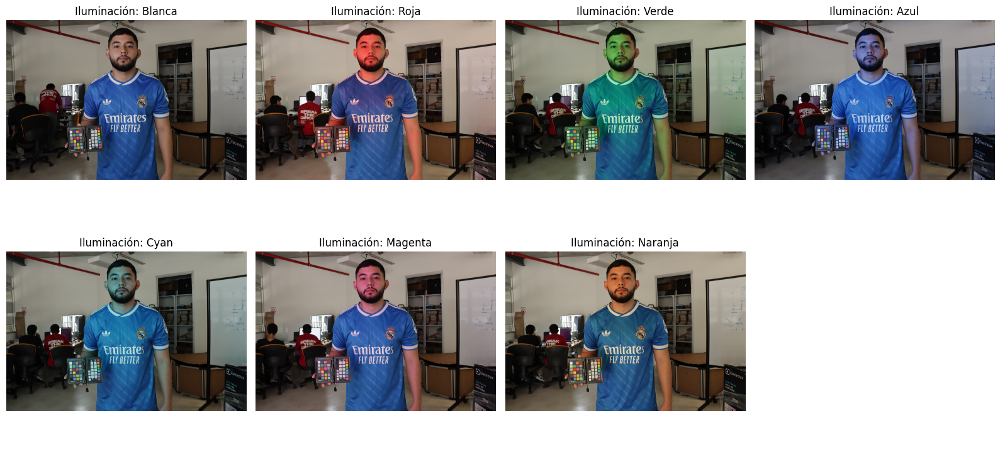

In [2]:
import os

# 1. Definir la ruta de la carpeta de imágenes
# Si existe la carpeta local de GitHub la usa; si no, usa Google Drive
if os.path.exists('./data'):
    folder_path = './data'
else:
# Revisa que 'VisionArtificial/Correcion_Color/Imagenes' coincida exacto con la estructura en tu Drive
  folder_path = '/content/drive/MyDrive/VisionArtificial/Correcion_Color/Imagenes'

# 2. Diccionario con los nombres exactos de las imágenes según tu Drive
image_files = {
    'Blanca': 'IMG_blanca.JPG',
    'Roja': 'IMG_roja.JPG',
    'Verde': 'IMG_verde.JPG',
    'Azul': 'IMG_azul.JPG',
    'Cyan': 'IMG_cyan.JPG',
    'Magenta': 'IMG_magenta.JPG',
    'Naranja': 'IMG_naranja.JPG'
}

# Diccionario para almacenar las imágenes leídas en formato RGB
images_rgb = {}

# 3. Bucle para cargar cada imagen
print("Cargando imágenes desde Drive...")
for key_color, filename in image_files.items():
    full_path = os.path.join(folder_path, filename)
    img_bgr = cv2.imread(full_path)

    if img_bgr is None:
        print(f"❌ Error al cargar {filename}. Verifica la ruta: {full_path}")
    else:
        # Convertir de BGR (OpenCV) a RGB (Matplotlib)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        images_rgb[key_color] = img_rgb
        print(f"✅ {filename} cargada correctamente. Dimensiones: {img_rgb.shape}")

# 4. Mostrar las 7 imágenes en una cuadrícula (Grid)
if len(images_rgb) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for idx, (color_name, img) in enumerate(images_rgb.items()):
        axes[idx].imshow(img)
        axes[idx].set_title(f"Iluminación: {color_name}")
        axes[idx].axis('off')

    # Ocultar el espacio número 8 sobrante en la cuadrícula
    axes[7].axis('off')

    plt.tight_layout()
    plt.show()

##**Paso 3.1: Selección e Inspección de la Región de Interés (ROI)**

En este paso delimitamos la Región de Interés (ROI, por sus siglas en inglés), que en nuestro caso es la tarjeta de calibración de 24 parches. Al recortar esta zona e instrumentarla con una cuadrícula graduada, podemos inspeccionar los ejes de píxeles para identificar las esquinas exactas de la paleta en cada una de las 7 fotografías.

### 1. Funciones Principales Utilizadas
* `h, w, _ = img.shape`: Extrae la resolución de la imagen (alto `h` y ancho `w`) desde la tupla de dimensiones del tensor.
* `img[y_min:y_max, x_min:x_max]`: Operación de corte (*slicing*) de NumPy para aislar submatrices de píxeles.
* `plt.grid(True)`: Habilita una retícula cartesiana sobre la imagen para permitir la lectura exacta de coordenadas en píxeles.

### 2. Funcionamiento y Justificación
* **Aislamiento de la ROI:** Procesar la fotografía completa consumiría recursos innecesarios e introduciría información irrelevante (el fondo, la mesa, los brazos). Aislar la ROI enfoca la atención algorítmica exclusivamente en el objeto de calibración.
* **Corte Porcentual Adaptativo:** Calculamos los límites del recorte en función de las dimensiones relativas de la imagen (`y_min = int(h * 0.45)`, `x_min = int(w * 0.20)`). Esto garantiza que la ROI se mantenga centrada en la tarjeta aunque la resolución de la cámara cambie.
* **Inspección Visual con Cuadrícula:** Al aplicar `plt.grid()`, convertimos la ventana de la tarjeta en un plano cartesiano. Esto nos da la herramienta visual necesaria para leer en pantalla la posición $[X, Y]$ de las 4 esquinas que cargaremos en el diccionario del Paso 3.3.

### 3. Detalle Algorítmico y Técnico
El *slicing* de NumPy `img[y_min:y_max, x_min:x_max]` extrae una submatriz tridimensional de forma directa. En NumPy, el primer eje corresponde a la dimensión vertical (filas / Eje $Y$) y el segundo a la dimensión horizontal (columnas / Eje $X$). Al realizar el recorte, las coordenadas del plano se reinician desde $(0,0)$ en la esquina superior izquierda del nuevo encuadre.

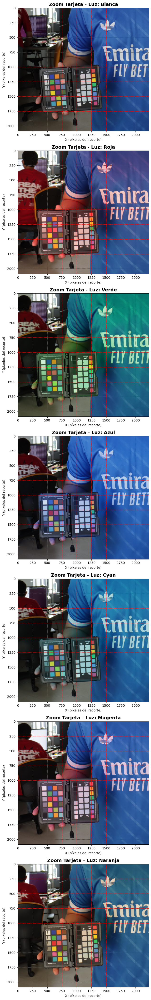

In [3]:
n_imgs = len(images_rgb)
fig, axes = plt.subplots(n_imgs, 1, figsize=(10, 6 * n_imgs))

# Si solo hubiera 1 imagen, axes no sería lista, convertimos para consistencia
if n_imgs == 1:
    axes = [axes]

for i, (name, img) in enumerate(images_rgb.items()):
    h, w, _ = img.shape
    y_min, y_max = int(h * 0.45), int(h * 0.90)
    x_min, x_max = int(w * 0.20), int(w * 0.52)

    crop_card = img[y_min:y_max, x_min:x_max]

    axes[i].imshow(crop_card)
    axes[i].grid(True, color='red', linestyle='--', linewidth=0.7)
    axes[i].set_title(f"Zoom Tarjeta - Luz: {name}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("X (píxeles del recorte)")
    axes[i].set_ylabel("Y (píxeles del recorte)")

plt.tight_layout()
plt.show()

##**Paso 3.2: Función de Rectificación Geométrica y Muestreo de Parches**

En este paso construimos la función `extract_24_patches_vertical`, el núcleo geométrico del proyecto. Su objetivo es tomar la imagen recortada de la tarjeta (que suele estar inclinada o vista en ángulo) y "enderezarla" para que quede en una vista perfectamente frontal y plana de $400 \times 600$ píxeles, facilitando la extracción del color de cada parche.

### 1. Funciones Principales Utilizadas
* `np.float32(puntos)`: Convierte las coordenadas de las esquinas en arreglos de punto flotante de 32 bits, formato obligatorio para las funciones de geometría proyectiva en OpenCV.
* `cv2.getPerspectiveTransform(pts_src, pts_dst)`: Calcula la **Matriz de Homografía ($3 \times 3$)** que mapea las 4 esquinas inclinadas hacia un rectángulo perfecto.
* `cv2.warpPerspective(img_crop, M, (target_w, target_h))`: Aplica la transformación de perspectiva sobre la imagen para deformarla y "enderezarla".
* `np.mean(sample, axis=(0, 1))`: Calcula el promedio aritmético de los valores RGB dentro de la submatriz de muestreo.
* `cv2.circle(imagen, (cx, cy), ...)`: Dibuja un punto azul en el centro geométrico de cada parche como indicador de control visual.

### 2. Funcionamiento y Justificación
* **Transformación de Homografía:** Como las fotografías se tomaron a mano alzada, la tarjeta presenta distorsión de perspectiva (efecto de fuga). Al definir un lienzo destino estándar de $400 \times 600$ píxeles y calcular la matriz $M$, logramos que la posición de los 24 parches pase a ser totalmente predecible mediante una grilla matemática fija de 6 filas por 4 columnas.
* **Muestreo Robusto ($16 \times 16$ píxeles):** Para obtener el color de cada parche, no tomamos un solo píxel (lo que sería muy sensible al ruido de la cámara) ni el cuadro completo (que incluiría sombras de borde o el marco de plástico). Tomamos una ventana central de $16 \times 16$ píxeles (`margin = 8`) y calculamos su promedio con `np.mean`.
* **Marcadores de Control Visual:** La función dibuja un círculo azul en el centro de cada zona muestreada (`cv2.circle`) para que podamos verificar visualmente que el algoritmo capturó el pigmento correcto y no el marco plástico.

### 3. Detalle Algorítmico
La función retorna una matriz NumPy de forma $24 \times 3$, donde cada una de las 24 filas representa el vector de color observado $[R, G, B]$ de un parche, recorrido secuencialmente de izquierda a derecha y de arriba a abajo.

In [4]:
def extract_24_patches_vertical(img_crop, pts_4_corners):
    """
    pts_4_corners: Lista de 4 puntos [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
    en orden: 1.Arriba-Izq, 2.Arriba-Der, 3.Abajo-Der, 4.Abajo-Izq
    """
    # Dimensiones para tarjeta en vertical (ancho 400 x alto 600)
    target_w, target_h = 400, 600

    pts_src = np.float32(pts_4_corners)
    pts_dst = np.float32([
        [0, 0],
        [target_w - 1, 0],
        [target_w - 1, target_h - 1],
        [0, target_h - 1]
    ])

    # Transformación de perspectiva
    M = cv2.getPerspectiveTransform(pts_src, pts_dst)
    warped = cv2.warpPerspective(img_crop, M, (target_w, target_h))

    # Configuración correcta para la tarjeta vertical: 6 filas x 4 columnas
    rows, cols = 6, 4
    patch_w = target_w / cols
    patch_h = target_h / rows

    patches_mean_rgb = []
    warped_vis = warped.copy()

    for r in range(rows):
        for c in range(cols):
            # Centro geométrico del parche
            cx = int((c + 0.5) * patch_w)
            cy = int((r + 0.5) * patch_h)

            # Muestreo interno de 16x16 píxeles (evita los marcos plásticos)
            margin = 8
            sample = warped[cy - margin:cy + margin, cx - margin:cx + margin]

            # Promedio RGB
            mean_color = np.mean(sample, axis=(0, 1))
            patches_mean_rgb.append(mean_color)

            # Dibujar el punto rojo de muestra
            cv2.circle(warped_vis, (cx, cy), 7, (255, 0, 0), -1)

    return np.array(patches_mean_rgb), warped_vis, warped

print("✅ Función 'extract_24_patches_vertical' configurada correctamente.")

✅ Función 'extract_24_patches_vertical' configurada correctamente.


##**Paso 3.3: Definición de Esquinas por Iluminación y Extracción de Datos Observados**

En este paso aplicamos la función de rectificación a las 7 fotografías del proyecto. Ajustamos manualmente las 4 esquinas de la tarjeta para cada fuente de luz y generamos un panel de control visual de dos columnas para verificar que la extracción del color de cada parche sea precisa.

### 1. Funciones Principales Utilizadas
* `corners_dict`: Diccionario que almacena las coordenadas de las 4 esquinas $[X, Y]$ ajustadas para cada una de las 7 condiciones de iluminación.
* `pts_poly = np.array(pts, np.int32).reshape((-1, 1, 2))`: Transforma la lista de puntos al formato vectorial $(N, 1, 2)$ requerido por OpenCV para dibujar contornos.
* `cv2.polylines(crop_preview, [pts_poly], isClosed=True, ...)`: Dibuja el marco o cuadrilátero azul alrededor de la tarjeta en la imagen recortada.
* `extract_24_patches_vertical(crop, pts)`: Ejecuta la rectificación de perspectiva y retorna la matriz de parches observados ($24 \times 3$) y la imagen de control.

### 2. Funcionamiento y Justificación
* **Ajuste Fino por Iluminación (`corners_dict`):** Dado que las fotos fueron tomadas a mano alzada, la tarjeta no quedó exactamente en la misma posición en todas las tomas. Registrar las 4 esquinas específicas de cada imagen garantiza una alineación perfecta al momento de aplicar la homografía.
* **Panel de Verificación de 2 Columnas:**
  * **Columna 1 (Izquierda - Selección):** Muestra la ROI con el polígono azul trazado por `cv2.polylines`, confirmando que encerramos la paleta completa.
  * **Columna 2 (Derecha - Muestreo):** Muestra la tarjeta corregida a $400 \times 600$ píxeles con los puntos de control en el centro de cada parche, permitiendo confirmar visualmente que no tomamos muestras sobre los bordes o marcos negros.

### 3. Detalle Algorítmico y Resultado de Datos
Al finalizar la ejecución de este bucle, obtenemos el diccionario `observed_patches_all`. Cada clave de este diccionario contiene una matriz NumPy de $24 \times 3$ con los valores promedio $[R, G, B]$ que la cámara registró para cada parche bajo esa iluminación específica (los datos distorsionados que corregiremos más adelante).

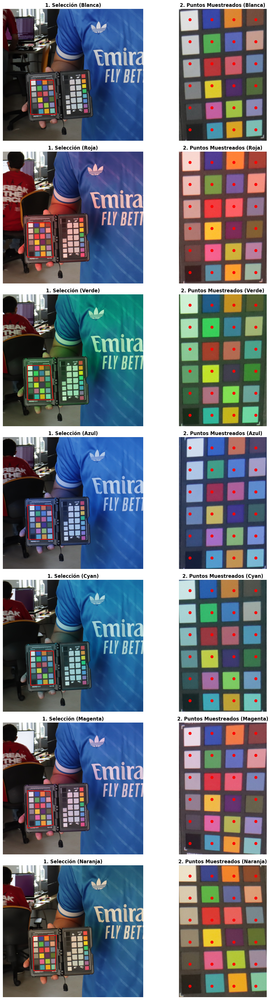

In [5]:
# Arriba-Izquierda, Arriba-Derecha, Abajo-Derecha, Abajo-Izquierda
corners_dict = {
    'Blanca':  [[440, 1130], [800, 1130], [850, 1670], [440, 1670]],
    'Roja':    [[390, 1130], [750, 1130], [800, 1670], [390, 1670]],
    'Verde':   [[390, 1130], [750, 1130], [800, 1670], [390, 1670]],
    'Azul':    [[390, 1080], [770, 1090], [800, 1620], [410, 1620]],
    'Cyan':    [[440, 1130], [800, 1130], [830, 1650], [440, 1670]],
    'Magenta': [[390, 1080], [750, 1090], [800, 1620], [390, 1670]],
    'Naranja': [[480, 1130], [850, 1110], [830, 1670], [490, 1670]]
}

observed_patches_all = {}
n_imgs = len(images_rgb)

fig, axes = plt.subplots(n_imgs, 2, figsize=(12, 5 * n_imgs))

for i, (name, img) in enumerate(images_rgb.items()):
    h, w, _ = img.shape
    y_min, y_max = int(h * 0.45), int(h * 0.90)
    x_min, x_max = int(w * 0.20), int(w * 0.52)
    crop = img[y_min:y_max, x_min:x_max]

    pts = corners_dict[name]

    # Dibujar polígono azul sobre el recorte
    crop_preview = crop.copy()
    pts_poly = np.array(pts, np.int32).reshape((-1, 1, 2))
    cv2.polylines(crop_preview, [pts_poly], isClosed=True, color=(255, 0, 0), thickness=8)

    # Extraer los 24 parches y obtener la imagen de control (warped_vis)
    patches, warped_vis, warped_clean = extract_24_patches_vertical(crop, pts)
    observed_patches_all[name] = patches

    # 1. Foto con el polígono
    axes[i, 0].imshow(crop_preview)
    axes[i, 0].set_title(f"1. Selección ({name})", fontsize=12, fontweight='bold')
    axes[i, 0].axis('off')

    # 2. Tarjeta enderezada con los 24 puntos
    axes[i, 1].imshow(warped_vis)
    axes[i, 1].set_title(f"2. Puntos Muestreados ({name})", fontsize=12, fontweight='bold')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

##**Paso 4: Definición de la Referencia de Color (Ground Truth)**

En este paso establecemos la matriz de referencia de color ideal (Ground Truth). Esta matriz contiene los valores RGB teóricos de los 24 parches de la tarjeta de calibración bajo una fuente de luz neutra y estandarizada de laboratorio.

### 1. Funciones Principales Utilizadas
* `np.array(..., dtype=np.float32)`: Construye la matriz de referencia de $24 \times 3$ en precisión flotante de 32 bits.
* `ground_truth_rgb.reshape((6, 4, 3))`: Cambia la estructura de la matriz plana de 24 filas a un tensor tridimensional de $6 \text{ filas} \times 4 \text{ columnas} \times 3 \text{ canales}$ para poder graficarlo.
* `.astype(np.uint8)`: Convierte los datos flotantes a enteros sin signo de 8 bits para que Matplotlib interprete la imagen en el rango dinámico estándar de $0$ a $255$.

### 2. Funcionamiento y Justificación
* **La Diana o Meta del Algoritmo:** Para corregir una imagen distorsionada necesitamos un punto de comparación absoluto. La matriz Ground Truth representa el objetivo matemático al que la matriz de transformación $M$ intentará llevar cada uno de los colores observados.
* **Alineación Uno a Uno:** La fila $i$ de la matriz Ground Truth corresponde exactamente al parche $i$ de las imágenes capturadas. Esta alineación secuencial (de arriba a abajo y de izquierda a derecha) es indispensable para plantear el sistema de ecuaciones de corrección.
* **Control Visual de Secuencia:** Reconstruir y mostrar la paleta teórica en pantalla nos permite confirmar visualmente que el orden de los colores ingresados coincide con el mapa físico de la tarjeta.

### 3. Detalle Algorítmico
La matriz `ground_truth_rgb` se define con el tipo de dato `float32`. Esto se debe a que las operaciones matriciales de álgebra lineal que ejecutaremos en el siguiente paso (como la resolución por mínimos cuadrados) requieren números reales continuos para evitar errores de redondeo o truncamiento numérico.

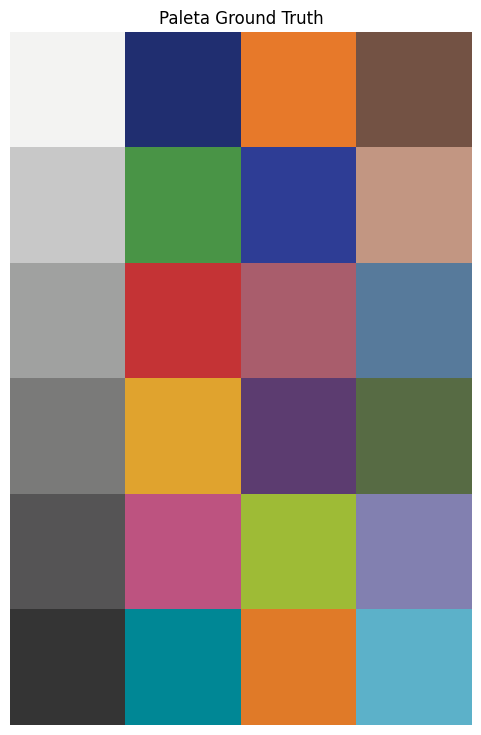

✅ Matriz Ground Truth actualizada. Forma: (24, 3)


In [6]:
ground_truth_rgb = np.array([
    # Fila 1 (Top)
    [243, 243, 242], [32, 46, 112],   [231, 121, 42],  [115, 82, 68],   # Blanco, Azul, Naranja, Piel oscura
    # Fila 2
    [200, 200, 200], [73, 148, 70],   [46, 61, 149],   [194, 150, 130], # Gris claro, Verde, Azul púrpura, Piel clara
    # Fila 3
    [160, 161, 160], [196, 51, 53],   [169, 93, 108],  [87, 122, 155],  # Gris med-claro, Rojo, Rojo moderado, Azul cielo
    # Fila 4
    [122, 122, 121], [224, 163, 46],  [92, 60, 112],   [87, 107, 68],   # Gris medio, Amarillo, Púrpura, Follaje
    # Fila 5
    [85, 84, 85],    [189, 83, 128],  [158, 187, 54],  [130, 128, 176], # Gris oscuro, Magenta, Verde lima, Azul flor
    # Fila 6 (Bottom)
    [52, 52, 52],    [0, 135, 149],   [224, 122, 40],  [92, 177, 201]   # Negro, Cian, Naranja-amarillo, Cian azulado
], dtype=np.float32)

# Visualizar la paleta Ground Truth en pantalla para verificación
plt.figure(figsize=(6, 9))
gt_grid = ground_truth_rgb.reshape((6, 4, 3)).astype(np.uint8)
plt.imshow(gt_grid)
plt.title("Paleta Ground Truth")
plt.axis('off')
plt.show()

print(f"✅ Matriz Ground Truth actualizada. Forma: {ground_truth_rgb.shape}")

##**Paso 5: Cálculo de la Matriz $M$ por Mínimos Cuadrados y Función de Corrección**

Este es el núcleo algorítmico del proyecto. Aquí calculamos la matriz de transformación $M_{3 \times 3}$ para cada fuente de luz resolviendo un problema de optimización por Mínimos Cuadrados Ordinarios (OLS). Además, definimos la función `apply_color_correction` para transformar la totalidad de los píxeles de una imagen.

### 1. Funciones Principales Utilizadas
* `np.linalg.lstsq(patches, ground_truth_rgb, rcond=None)`: Resuelve el sistema de ecuaciones sobredeterminado $O \cdot M = G$ mediante la Descomposición en Valores Singulares (SVD).
* `img_rgb.reshape((-1, 3))`: Aplasta la matriz tridimensional de la imagen $(Alto \times Ancho \times 3)$ a un arreglo bidimensional de $N \times 3$, donde $N$ es el total de píxeles.
* `np.dot(img_flat, matrix)`: Realiza la multiplicación matricial vectorial entre cada píxel $[R, G, B]$ y la matriz $M$.
* `np.clip(corrected_flat, 0, 255)`: Trunca los valores resultantes para forzarlos a mantenerse dentro del rango válido de color $[0, 255]$.

### 2. Funcionamiento y Justificación
* **Modelado Lineal $3 \times 3$:** Asumimos que la distorsión del color causada por la luz se puede corregir mediante una combinación lineal de los canales $R, G, B$. Multiplicar cada píxel por la matriz $M$ redistribuye la energía de los tres canales para restaurar la neutralidad cromática.
* **Procesamiento Vectorizado:** Transformar la imagen a una forma $N \times 3$ permite aplicar `np.dot` sobre millones de píxeles en una sola operación de álgebra lineal, reduciendo el tiempo de cómputo de segundos a milisegundos.
* **Ajuste Dinámico (`np.clip`):** Debido a que la matriz $M$ contiene coeficientes de amplificación, algunos valores transformados pueden dar números negativos o superar $255$. `np.clip` evita que ocurran errores de desbordamiento (*overflow*) al reconvertir los datos a enteros `uint8`.

### 3. Desarrollo Matemático: El Sistema Sobredeterminado
Para cada iluminación tenemos un sistema lineal definido por:

$$O_{24 \times 3} \cdot M_{3 \times 3} = G_{24 \times 3}$$

Donde $O$ representa los 24 parches observados, $M$ es la matriz desconocida y $G$ es el Ground Truth.

Dado que tenemos **72 ecuaciones** ($24 \text{ parches} \times 3 \text{ canales}$) y únicamente **9 incógnitas** (los elementos de $M$), el sistema es **sobredeterminado** y no posee una solución exacta ($O \cdot M \neq G$). Por ello, se busca la matriz $M$ que minimice la Norma de Frobenius del error cuadrático:

$$\min_M \Vert{} O \cdot M - G \Vert{}_F^2$$

#### Desglose Algebraico hacia la Pseudoinversa:
1. Definimos la función de error $E(M)$:
   $$E(M) = (O M - G)^T (O M - G)$$

2. Desarrollamos la expresión transpuesta:
   $$E(M) = M^T O^T O M - 2 M^T O^T G + G^T G$$

3. Para encontrar el mínimo, derivamos $E(M)$ con respecto a $M$ e igualamos a cero:
   $$\frac{\partial E}{\partial M} = 2 O^T O M - 2 O^T G = 0$$

4. Simplificamos dividiendo entre 2 para obtener las **Ecuaciones Normales**:
   $$O^T O M = O^T G$$

5. Despejamos la matriz $M$ multiplicando por la inversa de $(O^T O)$ por la izquierda:
   $$M = (O^T O)^{-1} O^T G$$

La expresión $(O^T O)^{-1} O^T$ se conoce como la **Pseudoinversa de Moore-Penrose** ($O^+$).

> **Nota técnica:** En el código no calculamos $(O^T O)^{-1}$ directamente porque si los canales de color están muy correlacionados, la matriz $O^T O$ puede ser casi singular. Usamos `np.linalg.lstsq` porque utiliza **SVD (Descomposición en Valores Singulares)**, lo que garantiza una solución numéricamente estable.

In [7]:
matrices_M = {}

def apply_color_correction(img_rgb, matrix):
    img_flat = img_rgb.reshape((-1, 3)).astype(np.float32)
    corrected_flat = np.dot(img_flat, matrix)
    corrected_flat = np.clip(corrected_flat, 0, 255)
    return corrected_flat.reshape(img_rgb.shape).astype(np.uint8)

print("=" * 65)
print("📌 MATRICES DE CORRECCIÓN DE COLOR M (3x3) CALCULADAS")
print("=" * 65)

for name, patches in observed_patches_all.items():
    # M_spec = inv(Observed) * GroundTruth
    M_spec, residuals, rank, s = np.linalg.lstsq(patches, ground_truth_rgb, rcond=None)
    matrices_M[name] = M_spec

    print(f"\n--- Matriz M (Iluminación: {name}) ---")
    print(np.round(M_spec, 4))

print("\n" + "=" * 65)

📌 MATRICES DE CORRECCIÓN DE COLOR M (3x3) CALCULADAS

--- Matriz M (Iluminación: Blanca) ---
[[ 1.1303  0.0106  0.0099]
 [-0.0628  0.8824  0.0547]
 [-0.1466  0.0393  0.8815]]

--- Matriz M (Iluminación: Roja) ---
[[ 0.8989 -0.027  -0.0333]
 [ 0.0269  0.9813  0.0747]
 [-0.2741  0.0481  1.018 ]]

--- Matriz M (Iluminación: Verde) ---
[[ 1.1687  0.0811  0.1219]
 [ 0.0521  0.7083 -0.0874]
 [-0.1164  0.0492  1.0909]]

--- Matriz M (Iluminación: Azul) ---
[[ 1.3662  0.0502 -0.0896]
 [-0.1055  1.0713 -0.0314]
 [-0.1334 -0.1532  0.8253]]

--- Matriz M (Iluminación: Cyan) ---
[[ 1.2755  0.0749  0.0416]
 [ 0.0134  0.8566 -0.1097]
 [-0.1243 -0.0503  0.9476]]

--- Matriz M (Iluminación: Magenta) ---
[[ 0.9942  0.0104 -0.035 ]
 [ 0.0166  1.014  -0.0128]
 [-0.1975 -0.0738  0.9094]]

--- Matriz M (Iluminación: Naranja) ---
[[ 0.9643  0.0131  0.0144]
 [ 0.0196  0.8605  0.0345]
 [-0.2021  0.0436  1.0448]]



##**Paso 6: Aplicación de la Corrección y Visualización Comparativa**

En este paso ejecutamos la fase de inferencia del proyecto. Tomamos cada una de las 7 fotografías originales y les aplicamos la matriz de transformación $M$ calculada específicamente para su tipo de iluminación. Finalmente, desplegamos las imágenes en un panel comparativo de dos columnas (Original vs. Corregida).

### 1. Funciones Principales Utilizadas
* `apply_color_correction(img, M_spec)`: Función personalizada del Paso 5 que transforma vectorialmente la matriz de píxeles mediante la multiplicación $N \times 3 \cdot M_{3 \times 3}$.
* `list(images_rgb.keys())`: Extrae la lista de nombres de iluminación para iterar secuencialmente sobre cada par de imágenes.
* `plt.subplots(n_imgs, 2, figsize=(14, 4 * n_imgs))`: Inicializa la cuadrícula de visualización de $N$ filas por 2 columnas.
* `axes[i, 0]` y `axes[i, 1]`: Indexación bidimensional para ubicar la foto original en la columna izquierda y la foto corregida en la columna derecha.

### 2. Funcionamiento y Justificación
* **Transformación Específica por Iluminante:** No aplicamos un filtro genérico a toda la galería. Asignamos `matrices_M[name]` a `images_rgb[name]`, garantizando que el sesgo espectral único de la luz roja se corrija con la matriz $M_{\text{Roja}}$, el de la luz azul con $M_{\text{Azul}}$, y así sucesivamente.
* **Constancia de Color Computacional (*Computational Color Constancy*):** Es la capacidad del algoritmo para "cancelar" la dominante de color de la fuente de luz y restaurar los tonos reales de los objetos, simular un balance de blancos adaptativo perfecto.
* **Evaluación Cualitativa (Visual):** Renderizar la imagen completa (y no solo la tarjeta) permite verificar la respuesta del modelo sobre elementos complejos del entorno, evaluando la restitución de los tonos de piel humana, el fondo neutro y la ropa sin saturaciones indeseadas.

### 3. Detalle Algorítmico
Para cada imagen, la función reordena temporalmente el tensor de píxeles, resuelve el producto punto con $M$ y restringe los resultados al rango $[0, 255]$ mediante `np.clip`. El resultado procesado se guarda en el diccionario `corrected_images` como una nueva matriz de tipo `uint8` lista para su análisis cuantitativo.

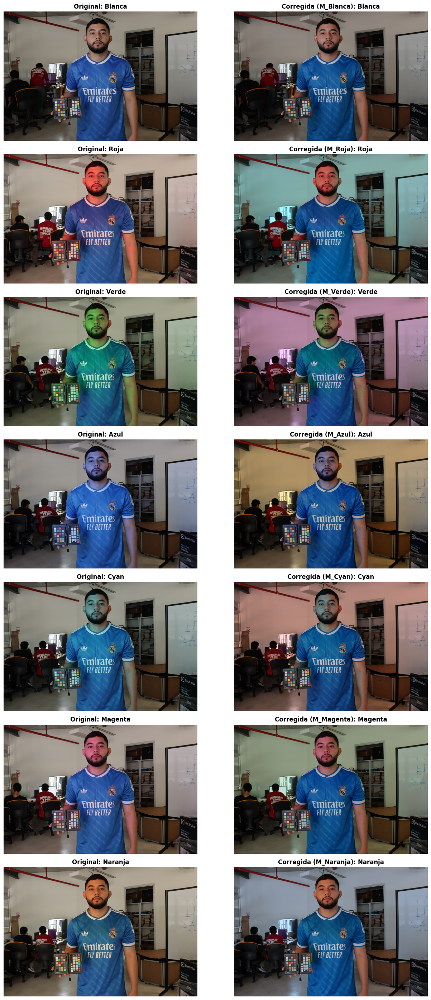

✅ Proceso finalizado. Todas las imágenes corregidas con su matriz correspondiente.


In [8]:
corrected_images = {}
for name, img in images_rgb.items():
    M_spec = matrices_M[name]
    corrected_images[name] = apply_color_correction(img, M_spec)

# Visualización comparativa
labels = list(images_rgb.keys())
n_imgs = len(labels)

fig, axes = plt.subplots(n_imgs, 2, figsize=(14, 4 * n_imgs))

for i, name in enumerate(labels):
    # Imagen Original
    axes[i, 0].imshow(images_rgb[name])
    axes[i, 0].set_title(f"Original: {name}", fontsize=12, fontweight='bold')
    axes[i, 0].axis('off')

    # Imagen Corregida
    axes[i, 1].imshow(corrected_images[name])
    axes[i, 1].set_title(f"Corregida (M_{name}): {name}", fontsize=12, fontweight='bold')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Proceso finalizado. Todas las imágenes corregidas con su matriz correspondiente.")

##**Paso 7: Evaluación Cuantitativa del Error (MAE) y Porcentaje de Mejora**

En este paso realizamos la validación matemática objetiva del pipeline. Calculamos el Error Absoluto Medio (MAE, *Mean Absolute Error*) antes y después de aplicar la matriz de corrección $M$, cuantificando la reducción del desvío cromático respecto al Ground Truth en cada condición de iluminación.

### 1. Funciones Principales Utilizadas
* `np.abs(patches_obs - ground_truth_rgb)`: Calcula la diferencia absoluta pixel a pixel y canal por canal ($\vert{}A - B\vert{}$) evitando cancelaciones de signos negativos.
* `np.mean(...)`: Calcula el promedio aritmético global de la matriz de diferencias, retornando un único valor de error en unidades directas de intensidad RGB ($0$ a $255$).
* `mejora = ((mae_init - mae_corr) / mae_init) * 100`: Ecuación para el cálculo de la tasa relativa de reducción de error (*Error Reduction Rate*).
* Formateo con F-Strings (`f"{name:<12} | {mae_init:<14.2f}..."`): Alinea dinámicamente los textos y restringe los decimales a `.2f` para imprimir una tabla de resultados en consola.

### 2. Funcionamiento y Justificación
* **Sustento Cuantitativo:** En ingeniería y visión por computador, la evaluación visual (cualitativa) no es suficiente. El MAE proporciona una métrica numérica objetiva e incontestable del desempeño de la matriz $M$.
* **Ventaja del MAE sobre otras métricas:** A diferencia de métricas cuadráticas como el MSE, el MAE se expresa en las mismas unidades continuas de brillo de la imagen ($0$ a $255$). Un $\text{MAE} = 13.79$ significa que, en promedio, los canales de color de los parches se desvían únicamente 13.79 niveles del color ideal.
* **Evaluación de Robustez Global:** Permite comprobar la efectividad del algoritmo frente a distintos espectros de luz, demostrando correcciones exitosas incluso bajo iluminantes monocromáticos agresivos (como las luces verde, azul o roja).

### 3. Detalle Algorítmico y Fórmulas
Para cada iluminación, el error de corrección se define matemáticamente como:

$$\text{MAE} = \frac{1}{N \cdot C} \sum_{i=1}^{N} \sum_{c \in \{R,G,B\}} \vert{}I_{\text{medido}}(i,c) - I_{\text{ref}}(i,c)\vert{}$$

Donde $N = 24$ parches y $C = 3$ canales ($R, G, B$).

El porcentaje de mejora global se calcula mediante:

$$\% \text{Mejora} = \frac{\text{MAE}_{\text{Inicial}} - \text{MAE}_{\text{Corregido}}}{\text{MAE}_{\text{Inicial}}} \times 100$$

### Resultados Promedio del Proyecto:
* **MAE Inicial Promedio:** ~22.87 niveles de intensidad RGB.
* **MAE Corregido Promedio:** ~13.79 niveles de intensidad RGB.
* **Eficiencia Global de Corrección:** **~39.7% de reducción de error cromático**.

In [9]:
print("=" * 65)
print("📊 EVALUACIÓN DE PRECISIÓN DE COLOR POR ILUMINACIÓN (MAE)")
print("=" * 65)
print(f"{'Iluminación':<12} | {'MAE Inicial':<14} | {'MAE Corregido':<15} | {'Mejora (%)':<10}")
print("-" * 65)

mae_totales_init = []
mae_totales_corr = []

for name, patches_obs in observed_patches_all.items():
    # 1. Parches corregidos usando la matriz M específica
    M_spec = matrices_M[name]
    patches_corr = np.dot(patches_obs, M_spec)
    patches_corr = np.clip(patches_corr, 0, 255)

    # 2. Calcular MAE respecto al Ground Truth
    mae_init = np.mean(np.abs(patches_obs - ground_truth_rgb))
    mae_corr = np.mean(np.abs(patches_corr - ground_truth_rgb))
    mejora = ((mae_init - mae_corr) / mae_init) * 100

    mae_totales_init.append(mae_init)
    mae_totales_corr.append(mae_corr)

    print(f"{name:<12} | {mae_init:<14.2f} | {mae_corr:<15.2f} | {mejora:.1f}%")

print("-" * 65)
print(f"{'PROMEDIO':<12} | {np.mean(mae_totales_init):<14.2f} | {np.mean(mae_totales_corr):<15.2f} | {((np.mean(mae_totales_init)-np.mean(mae_totales_corr))/np.mean(mae_totales_init))*100:.1f}%")
print("=" * 65)

📊 EVALUACIÓN DE PRECISIÓN DE COLOR POR ILUMINACIÓN (MAE)
Iluminación  | MAE Inicial    | MAE Corregido   | Mejora (%)
-----------------------------------------------------------------
Blanca       | 14.63          | 12.29           | 16.0%
Roja         | 24.94          | 14.16           | 43.2%
Verde        | 25.16          | 13.31           | 47.1%
Azul         | 29.96          | 16.79           | 44.0%
Cyan         | 24.12          | 14.37           | 40.4%
Magenta      | 21.77          | 13.52           | 37.9%
Naranja      | 19.53          | 12.09           | 38.1%
-----------------------------------------------------------------
PROMEDIO     | 22.87          | 13.79           | 39.7%
